# Hard active inverse-optimization research protocol

This permanently executed notebook demonstrates the MIN-only scientific benchmark with the built-in **uniform-random sequential-incenter** baseline. Every response is an exact observation $Y=X$ with no observation noise. The linear objective remains $F_\theta(S,x)=(S\odot\theta)^T x$; difficulty comes from coupled decisions, limited query information, small decision boundaries, and behavior-calibrated parameter noise.

The notebook uses one seed and eight interactions only so it renders quickly. Publication experiments should use the default five seeds and horizon 40. Clean cases require three consecutive zero-validation-regret rounds before stopping. Stochastic cases always run to the horizon. Final curves use a separate hidden test stream, never the validation stream.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root / 'src'))

from invoptlab.active import (
    ActiveResearchConfig,
    UniformRandomIncenterAlgorithm,
    build_active_research_scenarios,
    run_active_research_benchmark,
)

plt.style.use('seaborn-v0_8-whitegrid')
protocol = ActiveResearchConfig(
    seeds=(0,), horizon=8, candidate_count=16,
    validation_query_count=16, test_query_count=32,
    consecutive_validation_successes=3,
)
protocol.to_dict()

{'seeds': [0],
 'horizon': 8,
 'candidate_count': 16,
 'validation_query_count': 16,
 'test_query_count': 32,
 'validation_seed': 40001,
 'test_seed': 90001,
 'consecutive_validation_successes': 3,
 'zero_regret_tolerance': 1e-08,
 'learning_regret_threshold': 0.01}

## What is being tested

Every family uses the deterministic MIN expert and clean observations. The first three-dimensional family provides interpretable cone geometry; the remaining families isolate coupling, query information, or parameter noise without forming a Cartesian product.

In [2]:
scenarios = build_active_research_scenarios(protocol)
scenario_table = pd.DataFrame([
    {
        'family': s.metadata['research_family'],
        'd': s.dimension,
        'expert': s.expert.kind.value,
        'stochastic': s.metadata['stochastic'],
        'decision space': s.decision_space.kind.value,
        'query space': s.query_space.kind.value,
        'observation noise': s.observation_noise.kind.value,
        'parameter noise': s.parameter_noise.kind.value,
        'reason': s.metadata['rationale'],
    } for s in scenarios
])
scenario_table

,family,d,expert,stochastic,decision space,query space,observation noise,parameter noise,reason
0,geometry-cardinality-3d,3,min,False,fixed_cardinality,balanced,clean,none,A three-dimensional coupled case for cone and ...
1,cardinality-balanced-d20,20,min,False,fixed_cardinality,balanced,clean,none,Selecting exactly half the items reveals ranki...
2,cardinality-small-margin-d20,20,min,False,fixed_cardinality,sharp_boundary,clean,none,Nearby queries straddle small decision boundar...
3,knapsack-d20,20,min,False,structured,balanced,clean,none,Twenty unequal-weight items share a strict res...
4,dag-path-d18,18,min,False,structured,balanced,clean,none,Each observation compares complete source-to-s...
5,continuous-simplex-d10,10,min,False,continuous_polytope,balanced,clean,none,A simplex equality creates a genuinely coupled...
6,cardinality-sparse-queries-d20,20,min,False,fixed_cardinality,sparse,clean,none,Each interaction probes only three of twenty c...
7,cardinality-rare-informative-d20,20,min,False,fixed_cardinality,rare_informative,clean,none,Ninety percent of allowed queries lie in a ran...
8,cardinality-parameter-noise-mild-d20,20,min,True,fixed_cardinality,balanced,clean,isotropic,IID parameter perturbations alter about 5% of ...
9,cardinality-parameter-noise-moderate-d20,20,min,True,fixed_cardinality,balanced,clean,isotropic,IID parameter perturbations alter about 15% of...


## Run the same algorithm on all families

The algorithm receives only previous $(S,Y)$ observations, the public feasible-decision problem, and the permitted query candidates. Here $Y=X$ because the observation channel is clean, but the algorithm never receives $\theta^*$, the time-varying noisy parameter, validation/test queries, or any regret value.

In [3]:
result, research_summary = run_active_research_benchmark(
    {'uniform-incenter': lambda: UniformRandomIncenterAlgorithm(alternative_budget=64)},
    protocol,
    fail_fast=False,
)
estimate_failures = [run for run in result.runs if not run.evaluation['final_estimate_valid']]
print(f'execution completed={len(result.successful_runs)}, execution errors={len(result.failed_runs)}')
print(f'successful estimates={len(result.runs) - len(estimate_failures)}, failed estimates={len(estimate_failures)}')
assert not result.failed_runs
assert all(run.evaluation['metadata']['independent_from_stopping'] for run in result.runs)

execution completed=12, execution errors=0
successful estimates=10, failed estimates=2


In [4]:
final_rows = []
for run in result.runs:
    ev = run.evaluation
    final_rows.append({
        'family': run.scenario.metadata['research_family'],
        'steps': len(run.records),
        'stochastic': run.scenario.metadata['stochastic'],
        'status': 'SUCCESS' if ev['final_estimate_valid'] else 'FAILED',
        'failure type': None if ev['final_estimate_valid'] else ev['final_status'],
        'failure reason': ev['final_failure_reason'],
        'final regret': ev['final_normalized_regret'],
        'zero-regret rate': ev['final_zero_regret_rate'],
        'angular error (deg)': ev['final_angular_error_degrees'],
        'first regret <= 0.01': ev['first_threshold_step'],
        'stable regret <= 0.01': ev['stable_threshold_step'],
        'stopping reason': run.metadata['stopping_reason'] or 'fixed horizon',
    })
final_table = pd.DataFrame(final_rows).sort_values('final regret', ascending=False)
final_table.round(4)

,family,steps,stochastic,status,failure type,failure reason,final regret,zero-regret rate,angular error (deg),first regret <= 0.01,stable regret <= 0.01,stopping reason
6,cardinality-sparse-queries-d20,8,False,SUCCESS,None,None,0.2227,0.4688,39.1343,NaN,NaN,fixed horizon
5,continuous-simplex-d10,8,False,SUCCESS,None,None,0.0900,0.4688,39.7797,NaN,NaN,fixed horizon
4,dag-path-d18,8,False,SUCCESS,None,None,0.0898,0.4688,38.5126,NaN,NaN,fixed horizon
2,cardinality-small-margin-d20,8,False,SUCCESS,None,None,0.0383,0.2500,26.7733,NaN,NaN,fixed horizon
11,knapsack-parameter-noise-moderate-d20,8,True,SUCCESS,None,None,0.0091,0.5625,30.7980,2.0,2.0,fixed horizon
3,knapsack-d20,8,False,SUCCESS,None,None,0.0028,0.7188,15.8409,2.0,2.0,fixed horizon
8,cardinality-parameter-noise-mild-d20,8,True,SUCCESS,None,None,0.0026,0.6250,13.9646,3.0,3.0,fixed horizon
1,cardinality-balanced-d20,8,False,SUCCESS,None,None,0.0026,0.6250,13.9646,3.0,3.0,fixed horizon
7,cardinality-rare-informative-d20,8,False,SUCCESS,None,None,0.0025,0.7188,19.8482,2.0,2.0,fixed horizon
0,geometry-cardinality-3d,8,False,SUCCESS,None,None,0.0000,1.0000,5.8968,6.0,6.0,fixed horizon


## Three-dimensional cone after every interaction

For the $d=3$ cardinality family, colored sphere samples are the parameter directions remaining in $C_t$. The black arrow is $\theta^*$ and the red arrow is the sequential incenter estimate.

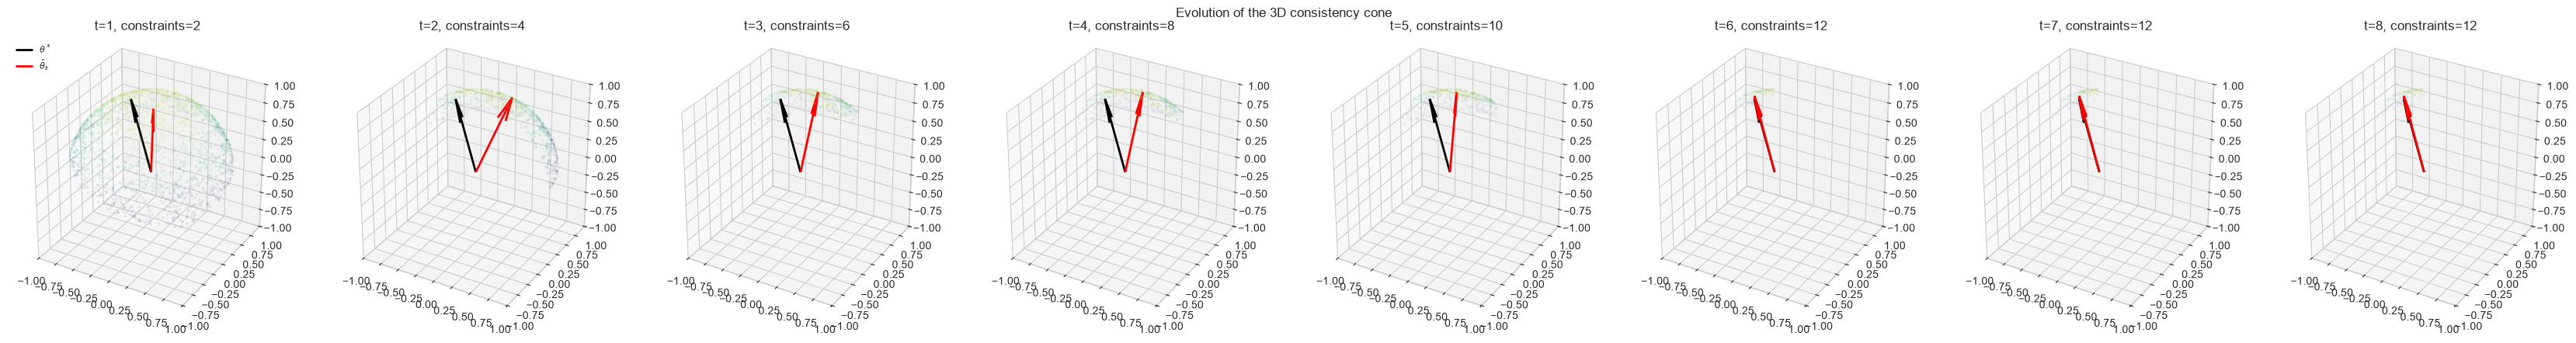

In [5]:
geometry_run = next(run for run in result.runs if run.scenario.metadata['research_family'] == 'geometry-cardinality-3d')
sphere_rng = np.random.default_rng(2026)
directions = sphere_rng.normal(size=(5000, 3))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
figure = plt.figure(figsize=(4.2 * len(geometry_run.records), 4.2))
truth = geometry_run.true_theta / np.linalg.norm(geometry_run.true_theta)
for panel, record in enumerate(geometry_run.records, start=1):
    axis = figure.add_subplot(1, len(geometry_run.records), panel, projection='3d')
    normals = np.asarray(record.update_diagnostics.get('constraint_normals', []), dtype=float)
    feasible = np.ones(len(directions), dtype=bool) if normals.size == 0 else np.all(normals @ directions.T <= 1e-8, axis=0)
    points = directions[feasible]
    axis.scatter(points[:, 0], points[:, 1], points[:, 2], s=3, alpha=.25, c=points[:, 2], cmap='viridis')
    estimate = record.theta_hat_after
    estimate = estimate / np.linalg.norm(estimate) if np.linalg.norm(estimate) > 1e-12 else estimate
    axis.quiver(0, 0, 0, *truth, color='black', linewidth=2, label=r'$\theta^*$')
    axis.quiver(0, 0, 0, *estimate, color='red', linewidth=2, label=r'$\hat\theta_t$')
    axis.set(title=f"t={record.step}, constraints={normals.shape[0]}", xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
    axis.set_box_aspect((1, 1, 1))
    if panel == 1: axis.legend(loc='upper left', fontsize=8)
figure.suptitle('Evolution of the 3D consistency cone')
figure.tight_layout()
plt.show()

## Regret at every interaction

Every panel below is a complete test-regret trajectory, not only a final value. The dashed line is the protocol's 0.01 learning threshold. A missing point means the estimator explicitly failed; no artificial regret is computed for an invalid estimate.

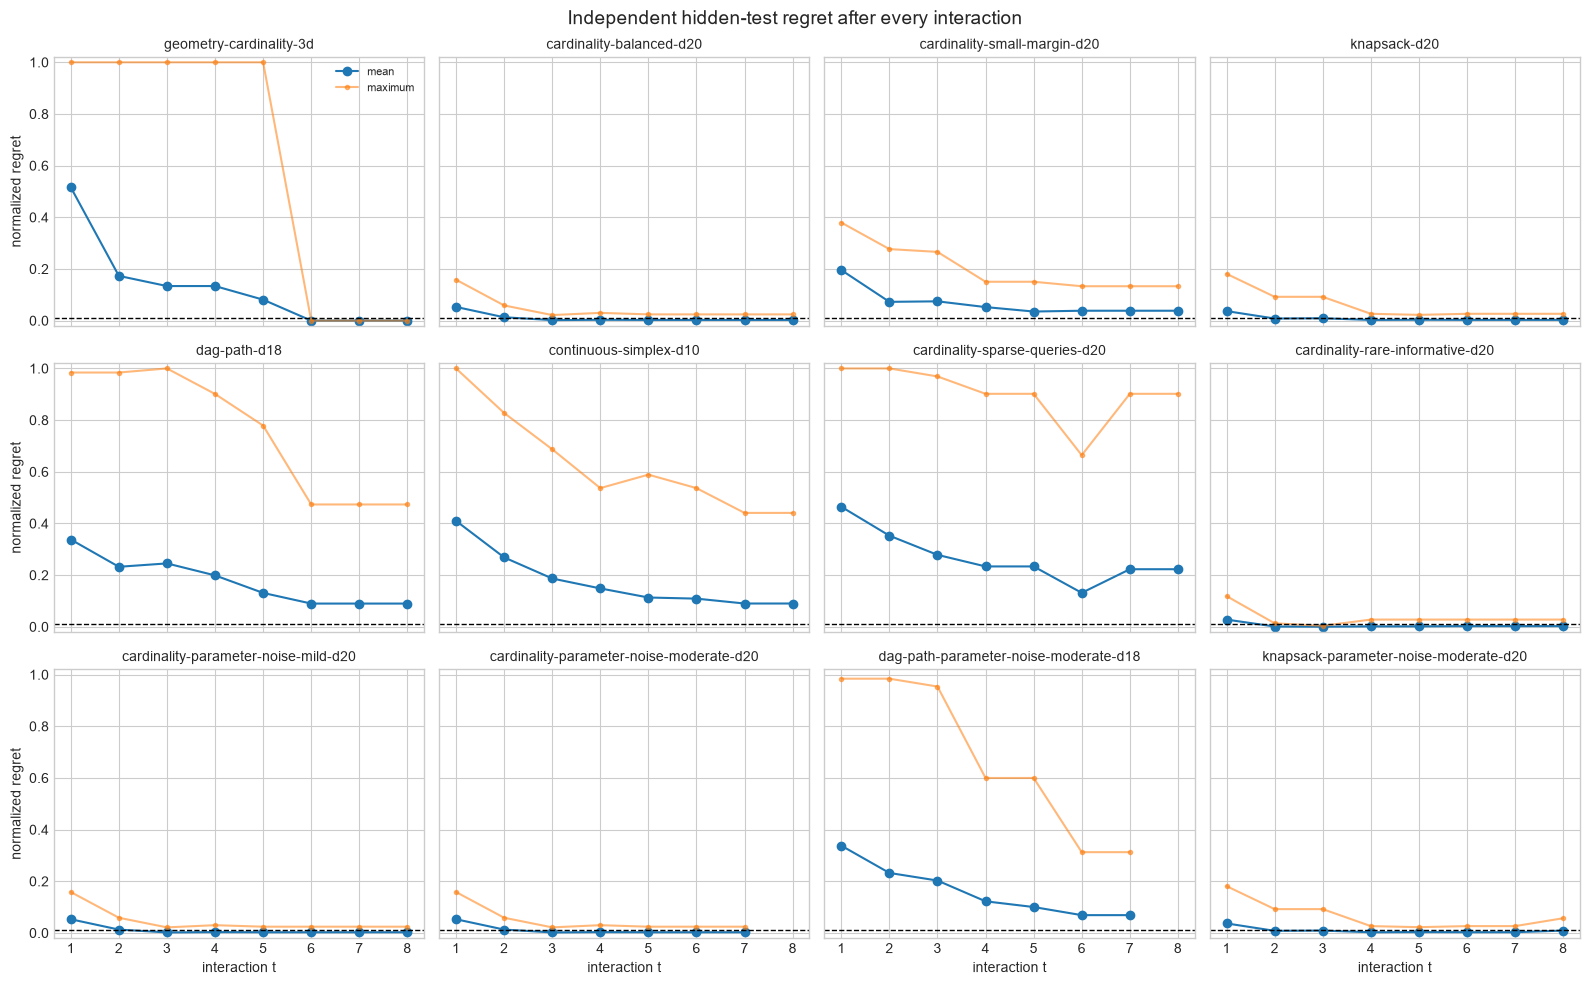

In [6]:
trajectory_rows = []
for run in result.runs:
    ev = run.evaluation
    for i, record in enumerate(run.records):
        trajectory_rows.append({
            'family': run.scenario.metadata['research_family'],
            'step': record.step,
            'status': ev['estimate_status_history'][i],
            'regret': ev['normalized_regret_history'][i],
            'max regret': ev['maximum_normalized_regret_history'][i],
            'zero-regret rate': ev['zero_regret_rate_history'][i],
            'angular error': ev['angular_error_history_degrees'][i],
            'constraints': record.update_diagnostics.get('constraint_count', 0),
            'inradius': record.update_diagnostics.get('incenter_radius', 0.0),
        })
trajectory = pd.DataFrame(trajectory_rows)
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for axis, (family, frame) in zip(axes.flat, trajectory.groupby('family', sort=False)):
    axis.plot(frame['step'], frame['regret'], marker='o', label='mean')
    axis.plot(frame['step'], frame['max regret'], marker='.', alpha=.55, label='maximum')
    axis.axhline(protocol.learning_regret_threshold, color='black', ls='--', lw=1)
    axis.set_title(family, fontsize=10)
    axis.set_ylim(-.02, 1.02)
for axis in axes[-1]: axis.set_xlabel('interaction t')
for axis in axes[:, 0]: axis.set_ylabel('normalized regret')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Independent hidden-test regret after every interaction', fontsize=14)
fig.tight_layout()
plt.show()

## Parameter recovery and behavioral correctness through time

These measurements answer different questions. Angular error measures recovery of $\theta^*$; zero-regret rate measures how often the estimate induces exactly the correct test decision. Failed estimates are left blank rather than being displayed as 90 or 180 degrees.

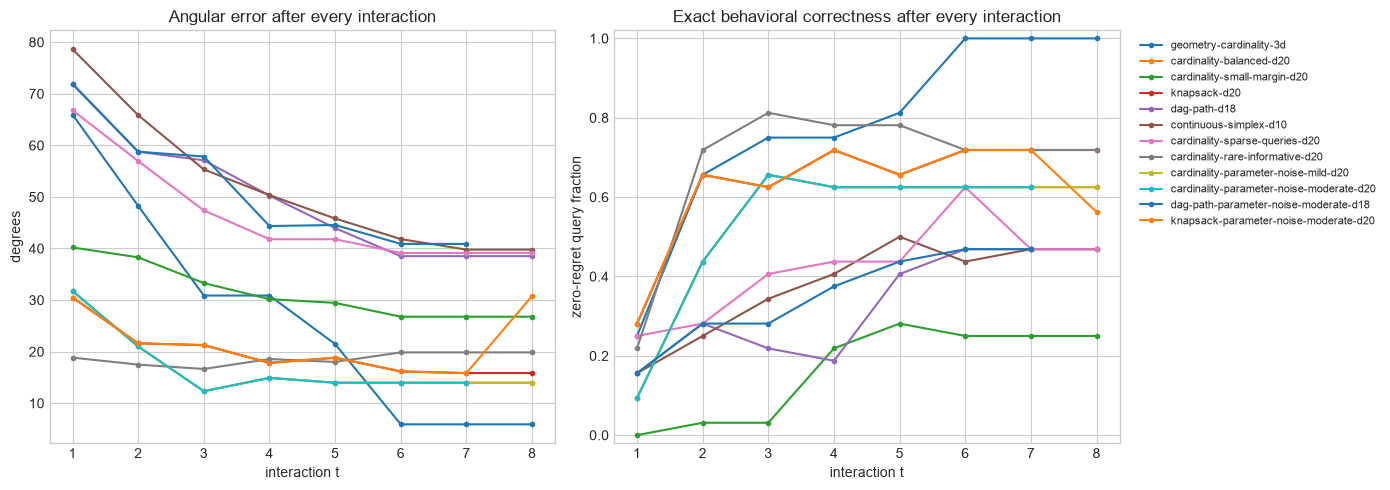

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for family, frame in trajectory.groupby('family', sort=False):
    axes[0].plot(frame['step'], frame['angular error'], marker='.', label=family)
    axes[1].plot(frame['step'], frame['zero-regret rate'], marker='.', label=family)
axes[0].set(title='Angular error after every interaction', xlabel='interaction t', ylabel='degrees')
axes[1].set(title='Exact behavioral correctness after every interaction', xlabel='interaction t', ylabel='zero-regret query fraction', ylim=(-.02, 1.02))
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

## Cone estimator evolution at every interaction

The first family provides explicit three-dimensional cone plots. For every dimension, the number of consistency hyperplanes and normalized inradius are also plotted at every time step.

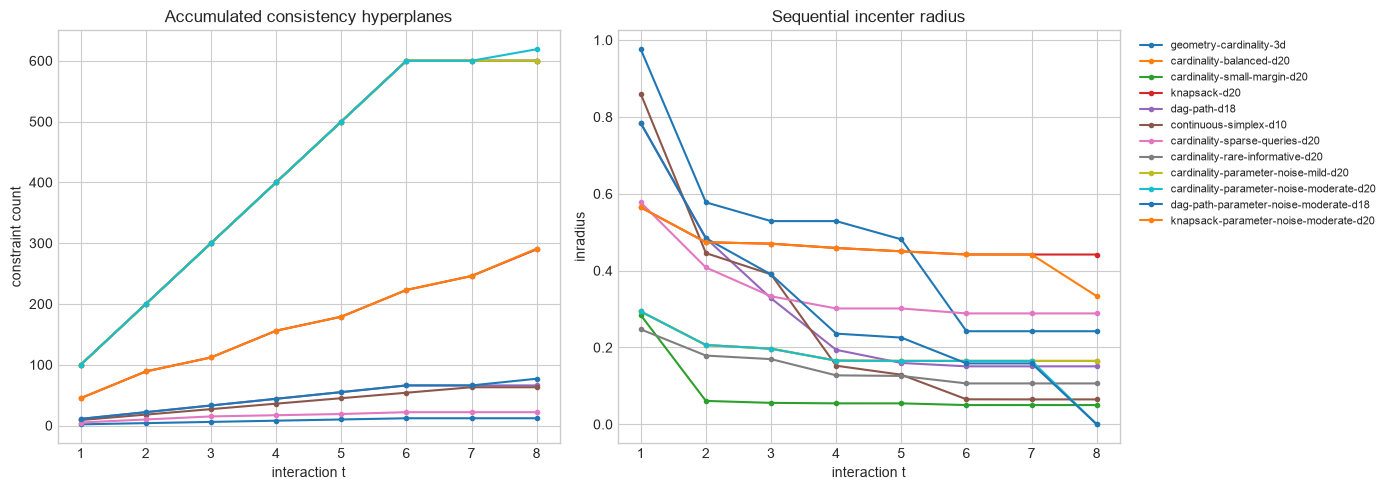

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for family, frame in trajectory.groupby('family', sort=False):
    axes[0].plot(frame['step'], frame['constraints'], marker='.', label=family)
    axes[1].plot(frame['step'], frame['inradius'], marker='.', label=family)
axes[0].set(title='Accumulated consistency hyperplanes', xlabel='interaction t', ylabel='constraint count')
axes[1].set(title='Sequential incenter radius', xlabel='interaction t', ylabel='inradius')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

## Noise calibration and stopping audit

Calibration reports the empirical probability of changing the expert's decision, which is more interpretable than a raw $\sigma$. The stopping audit shows that stochastic families use the fixed horizon and clean families require sustained validation success.

In [9]:
calibration_rows = []
stopping_rows = []
for run in result.runs:
    family = run.scenario.metadata['research_family']
    for channel, values in run.metadata.get('noise_calibration', {}).items():
        calibration_rows.append({'family': family, 'channel': channel, **values})
    stopping_rows.append({
        'family': family,
        'stochastic': run.scenario.metadata['stochastic'],
        'executed steps': len(run.records),
        'external stopping enabled': run.metadata['external_stopping_enabled'],
        'criterion met': run.metadata['stopping_criterion_met'],
        'reason': run.metadata['stopping_reason'] or 'fixed horizon',
    })
print('Behavioral calibration')
display(pd.DataFrame(calibration_rows).round(4))
print('Stopping audit')
display(pd.DataFrame(stopping_rows))

Behavioral calibration


,family,channel,target_change_rate,achieved_change_rate,effective_strength,trials
0,cardinality-parameter-noise-mild-d20,isotropic_parameter,0.05,0.0781,0.0102,64
1,cardinality-parameter-noise-moderate-d20,isotropic_parameter,0.15,0.1875,0.0530,64
2,dag-path-parameter-noise-moderate-d18,isotropic_parameter,0.15,0.1719,0.0381,64
3,knapsack-parameter-noise-moderate-d20,isotropic_parameter,0.15,0.1719,0.0737,64


Stopping audit


,family,stochastic,executed steps,external stopping enabled,criterion met,reason
0,geometry-cardinality-3d,False,8,True,False,fixed horizon
1,cardinality-balanced-d20,False,8,True,False,fixed horizon
2,cardinality-small-margin-d20,False,8,True,False,fixed horizon
3,knapsack-d20,False,8,True,False,fixed horizon
4,dag-path-d18,False,8,True,False,fixed horizon
5,continuous-simplex-d10,False,8,True,False,fixed horizon
6,cardinality-sparse-queries-d20,False,8,True,False,fixed horizon
7,cardinality-rare-informative-d20,False,8,True,False,fixed horizon
8,cardinality-parameter-noise-mild-d20,True,8,False,False,fixed horizon
9,cardinality-parameter-noise-moderate-d20,True,8,False,False,fixed horizon


## How to use the result

All twelve rows use MIN and clean observations; four rows introduce parameter noise before the MIN decision is computed. Publication conclusions require the default five seeds and horizon 40. A good active algorithm should improve the coupled and information-limited trajectories and remain stable under parameter noise. A nonzero angular error with zero regret is possible and should be reported honestly: it means behavior was identified more precisely than the numerical parameter direction.